### Proyecto final: Modelo de clasificación de imágenes de resonancias magnéticas de cerebro para detección de tumor (glioma, meningioma y pituitaria)

Objetivo:
Desarrollar una red neuronal convolucional capaz de clasificar resonancias magnéticas cerebrales en cuatro categorías:

- Glioma
- Meningioma
- Pituitary
- No Tumor

La resonancia magnética es el estándar de oro en medicina para visualizar tejidos blandos, ya que permite diferenciar perfectamente la materia gris, la materia blanca y los distintos tipos de tejidos tumorales, a diferencia de los Rayos X o el TAC que sirven mejor para los huesos.
Al analizar los cortes anatómicos en 2D de la RM (axiales, coronales o sagitales), los radiólogos prestan atención a esta "sensibilidad visual":

- Pérdida de Simetría: El cerebro sano es simétrico. Si al comparar el hemisferio izquierdo con el derecho notan masas extrañas de un solo lado, es la primera señal de alerta.

- Efecto de Masa (Mass Effect): Como el cráneo es rígido, un tumor en crecimiento "empuja" y deforma el tejido sano. Los doctores buscan ventrículos aplastados o la desviación de la línea media del cerebro.

- Alteración de Intensidades: Dependiendo de la técnica de la máquina, los tumores brillan de forma anormal (hiperintensos) o se ven muy oscuros (hipointensos) en comparación con la textura del cerebro circundante.

- Edema: Es muy común ver una zona hinchada o un halo de retención de líquidos alrededor de la masa tumoral.




El cerebro es un objeto tridimensional, y la máquina de resonancia magnética captura un "volumen" 3D completo. Sin embargo, para poder analizarlas visualmente en una pantalla (y para pasárselas a una red neuronal Convolucional 2D), ese cerebro en 3D se "rebana" matemáticamente en múltiples imágenes planas en 2D. Cada una de esas imágenes individuales es un corte.

Tipos de cortes:

Corte Axial (o Transversal): Es la vista desde arriba (o desde abajo). Imagina que el paciente está de pie y la imagen se toma de forma horizontal, paralela al suelo.

Corte Coronal: Es la vista frontal. Imagina que estás mirando al paciente cara a cara y la imagen se corta verticalmente, de oreja a oreja.

Corte Sagital: Es la vista de perfil (de lado). Imagina que ves al paciente desde un costado y el corte va desde la nariz hacia la nuca, dividiendo el cerebro en hemisferio izquierdo y derecho.

Finalmente,
se plantea la siguiente estructura:

Modelo 1: tumor vs notumor

        ↓
Si predice tumor

        ↓
Modelo 2: glioma vs meningioma vs pituitary

### EDA

PARTE 1. Estructura del dataset

In [4]:
#librerías
import os
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np

import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random 
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling)
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


1. Exploración de datos

In [5]:
#DEFINIR  RUTAS
train_dir = Path("../data/processed/train")
test_dir = Path("../data/processed/test")

classes = sorted([folder.name for folder in train_dir.iterdir() if folder.is_dir()])
print("tipos de tumores:", classes)

tipos de tumores: ['glioma', 'meningioma', 'notumor', 'pituitary']


2. Cantidad de imágenes: Se hace un dataframe para luego visualizar imágenes por clases

In [6]:
data = []

for split, folder in [("train", train_dir), ("test", test_dir)]:
    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            label = class_folder.name
            
            for img_path in class_folder.glob("*"):
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode
                        format_img = img.format
                        
                    data.append({
                        "path": str(img_path),
                        "split": split,
                        "label": label,
                        "ancho": width,
                        "largo": height,
                        "mode": mode,
                        "format": format_img
                    })
                    
                except Exception as e:
                    data.append({
                        "path": str(img_path),
                        "tipo_split": split,
                        "label": label,
                        "ancho": None,
                        "largo": None,
                        "mode": None,
                        "format": None
                    })

df_images = pd.DataFrame(data)
df_images.head()


,path,split,label,ancho,largo,mode,format
0,../data/processed/train/glioma/Tr-gl_1.jpg,train,glioma,512,512,L,JPEG
1,../data/processed/train/glioma/Tr-gl_10.jpg,train,glioma,512,512,L,JPEG
2,../data/processed/train/glioma/Tr-gl_100.jpg,train,glioma,512,512,L,JPEG
3,../data/processed/train/glioma/Tr-gl_1000.jpg,train,glioma,512,512,L,JPEG
4,../data/processed/train/glioma/Tr-gl_1001.jpg,train,glioma,512,512,L,JPEG


In [7]:
df_images.shape

(7200, 7)

In [8]:
df_images.groupby(["split", "label"]).size()

split  label     
test   glioma         400
       meningioma     400
       notumor        400
       pituitary      400
train  glioma        1400
       meningioma    1400
       notumor       1400
       pituitary     1400
dtype: int64

In [9]:
df_images.groupby(["split", "label"]).size().unstack()

label,glioma,meningioma,notumor,pituitary
split,,,,
test,400,400,400,400
train,1400,1400,1400,1400


3. Balanceo de imágenes en split

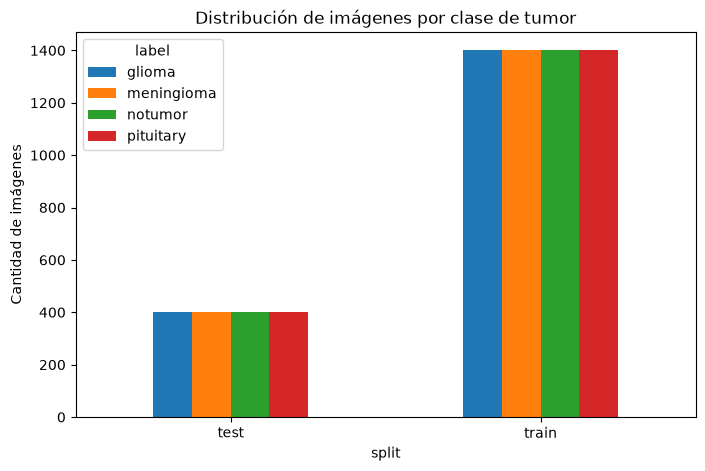

In [10]:
df_images.groupby(["split", "label"]).size().unstack().plot(kind="bar", figsize=(8,5))

plt.title("Distribución de imágenes por clase de tumor")
plt.xlabel("split")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=0)
plt.show()

Conclusiones:

- El dataset contiene 7200 imágenes de resonancias magnéticas cerebrales distribuidas en cuatro categorías: glioma, meningioma, pituitary y notumor.
- Se visualiza que el dataset está bien balanceado si se considera hacer un modelo multiclase, sin embargo, si se quisiera hacer un modelo binario tumor/no tumor, estaría desbalanceado, ya que se tiene 1800 imágenes de no tumor

PARTE 2. Calidad de las imágenes

Colores de la data de entrenamiento

In [11]:
modes = []

for img_path in Path("../data/processed/train").rglob("*.*"):
    
    img = Image.open(img_path)
    
    modes.append(img.mode)

Counter(modes)

print("Modos de imagen encontrados:", set(modes))
print("Cantidad por modos:",Counter(modes))

Modos de imagen encontrados: {'RGB', 'RGBA', 'L', 'P'}
Cantidad por modos: Counter({'RGB': 3238, 'L': 2358, 'RGBA': 3, 'P': 1})


Notas:

'RGB': 3238, (escala rojo, verde y azul)

'L': 2358, (escala grises)

'RGBA': 3, (Transparencia)

'P': 1 (Formato indexado)

Distribución de tamaños

In [12]:
#top 20 tamaño de imágenes por cantidad
df_images.groupby(["ancho", "largo"]).size()\
         .sort_values(ascending=False)\
         .head(20)

ancho  largo
512    512      5014
225    225       338
630    630        90
201    251        57
228    221        51
232    217        50
236    236        48
442    442        48
150    198        44
200    252        43
428    417        42
227    222        39
173    201        36
206    244        35
256    256        33
192    192        31
218    231        29
201    250        29
215    234        28
227    262        27
dtype: int64

Se visualiza que la mayoría de las imágenes son cuadradas

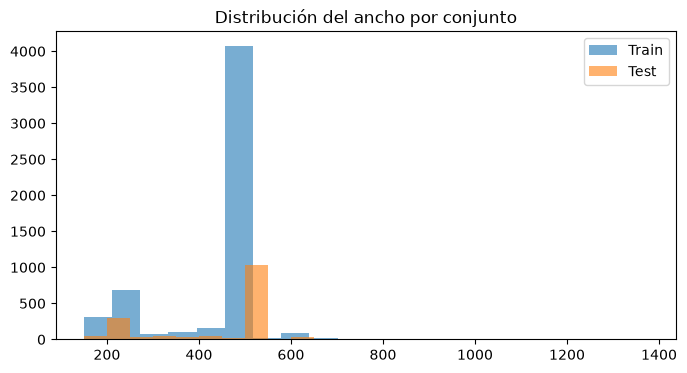

In [13]:
#distribución de cantidad de imágenes por ancho en pixeles
plt.figure(figsize=(8,4))

plt.hist(
    df_images[df_images["split"]=="train"]["ancho"],
    bins=20,
    alpha=0.6,
    label="Train"
)

plt.hist(
    df_images[df_images["split"]=="test"]["ancho"],
    bins=20,
    alpha=0.6,
    label="Test"
)

plt.legend()
plt.title("Distribución del ancho por conjunto")

plt.show()

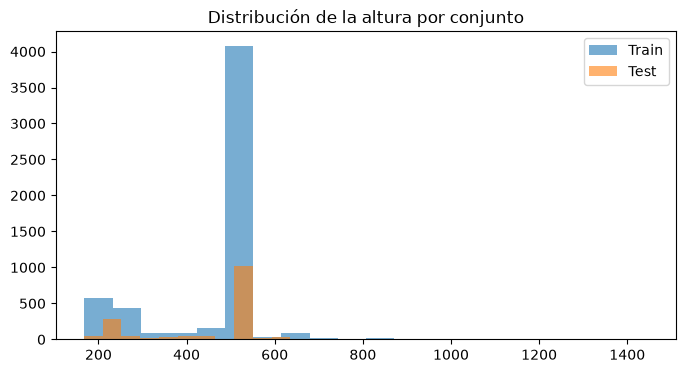

In [14]:
plt.figure(figsize=(8,4))

plt.hist(
    df_images[df_images["split"]=="train"]["largo"],
    bins=20,
    alpha=0.6,
    label="Train"
)

plt.hist(
    df_images[df_images["split"]=="test"]["largo"],
    bins=20,
    alpha=0.6,
    label="Test"
)

plt.legend()
plt.title("Distribución de la altura por conjunto")

plt.show()

In [15]:
#Valores estadísticos de los tamaños de las imágenes
df_images[["ancho","largo"]].describe()

,ancho,largo
count,7200.000000,7200.000000
mean,453.302917,456.899167
std,130.048964,124.402496
min,150.000000,167.000000
25%,442.000000,449.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1375.000000,1446.000000


In [16]:
# Imágenes donde ancho y alto son distintos
df_images[df_images["ancho"] != df_images["largo"]].shape[0]

1533

In [17]:
# Porcentaje de imágenes no cuadradas
(df_images["ancho"] != df_images["largo"]).mean() * 100


np.float64(21.291666666666668)

In [95]:
# Las 10 imágenes con mayor diferencia entre ancho y alto
df_images["diferencia"] = abs(df_images["ancho"] - df_images["largo"])

df_images.sort_values(
    "diferencia",
    ascending=False
)[["path","ancho","largo","diferencia"]].head(10)

,path,ancho,largo,diferencia
3208,../data/processed/train/notumor/Tr-no_1366.jpg,1280,720,560
3559,../data/processed/train/notumor/Tr-no_421.jpg,1000,583,417
3737,../data/processed/train/notumor/Tr-no_582.jpg,1000,583,417
4198,../data/processed/train/notumor/Tr-no_998.jpg,853,480,373
3020,../data/processed/train/notumor/Tr-no_1197.jpg,1000,714,286
3130,../data/processed/train/notumor/Tr-no_1296.jpg,642,361,281
6472,../data/processed/test/notumor/Te-no_164.jpg,642,361,281
2821,../data/processed/train/notumor/Tr-no_1017.jpg,642,361,281
6513,../data/processed/test/notumor/Te-no_200.jpg,642,361,281
6524,../data/processed/test/notumor/Te-no_210.jpg,642,361,281


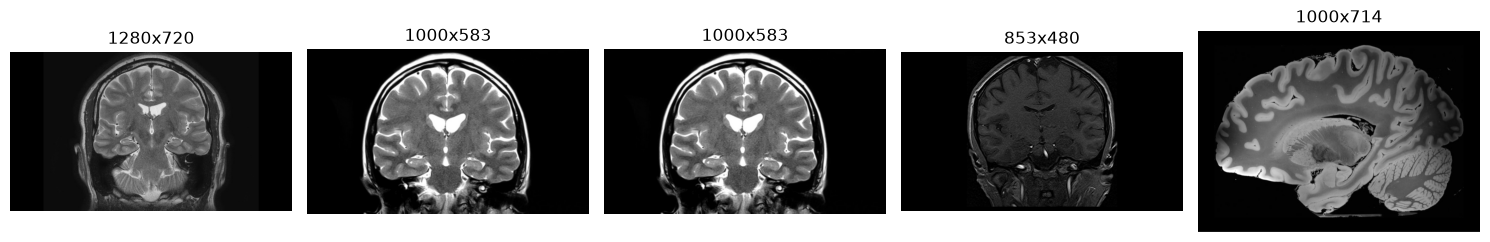

In [93]:
#revisión de outliers, casos donde las fotos son más rectangulares que cuadradas, para ver si es necesario recortarlas o descartarlas
ejemplos = (
    df_images
    .sort_values("diferencia", ascending=False)
    .head(5) #los 5 primeros ejemplos con mayor diferencia entre ancho y alto
)

fig, axes = plt.subplots(1, 5, figsize=(15,4))

for ax, (_, row) in zip(axes, ejemplos.iterrows()):

    img = Image.open(row["path"])

    ax.imshow(img, cmap="gray")
    ax.set_title(f'{row["ancho"]}x{row["largo"]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

Revisión de imágenes corruptas: no legibles por ordenador

In [20]:
for split in ["train", "test"]:

    bad_images = []

    for img_path in Path(f"../data/processed/{split}").rglob("*.*"):

        try:
            Image.open(img_path).verify()

        except:
            bad_images.append(img_path)

    print(f"Imágenes corruptas en {split}: {len(bad_images)}")

Imágenes corruptas en train: 0
Imágenes corruptas en test: 0


Conclusiones generales

- La resolución de imágenes que predomina es 512×512 píxele, siendo aprox 5mil del dataset.
- Ell 21% del dataset son imágenes rectangulares, esto hay que tenerlo en cuanto cuando se haga la preparación de los datos para el modelado.
- En las características del tamaño de las imágenes se visualiza que hay imágenes pequeñas de 150 px pero también hay tamaños muy grandes , como de 1375 px aprox. Sin embargo, estos son de poca cantidad.
- La mayoría de imágenes están en RGB y en escala a grises.
- Una anotación importante es que será necesario unificar el formato de color y redimensionar las imágenes antes del entrenamiento.

PARTE 3. Exploración visual

Visualización de imágenes

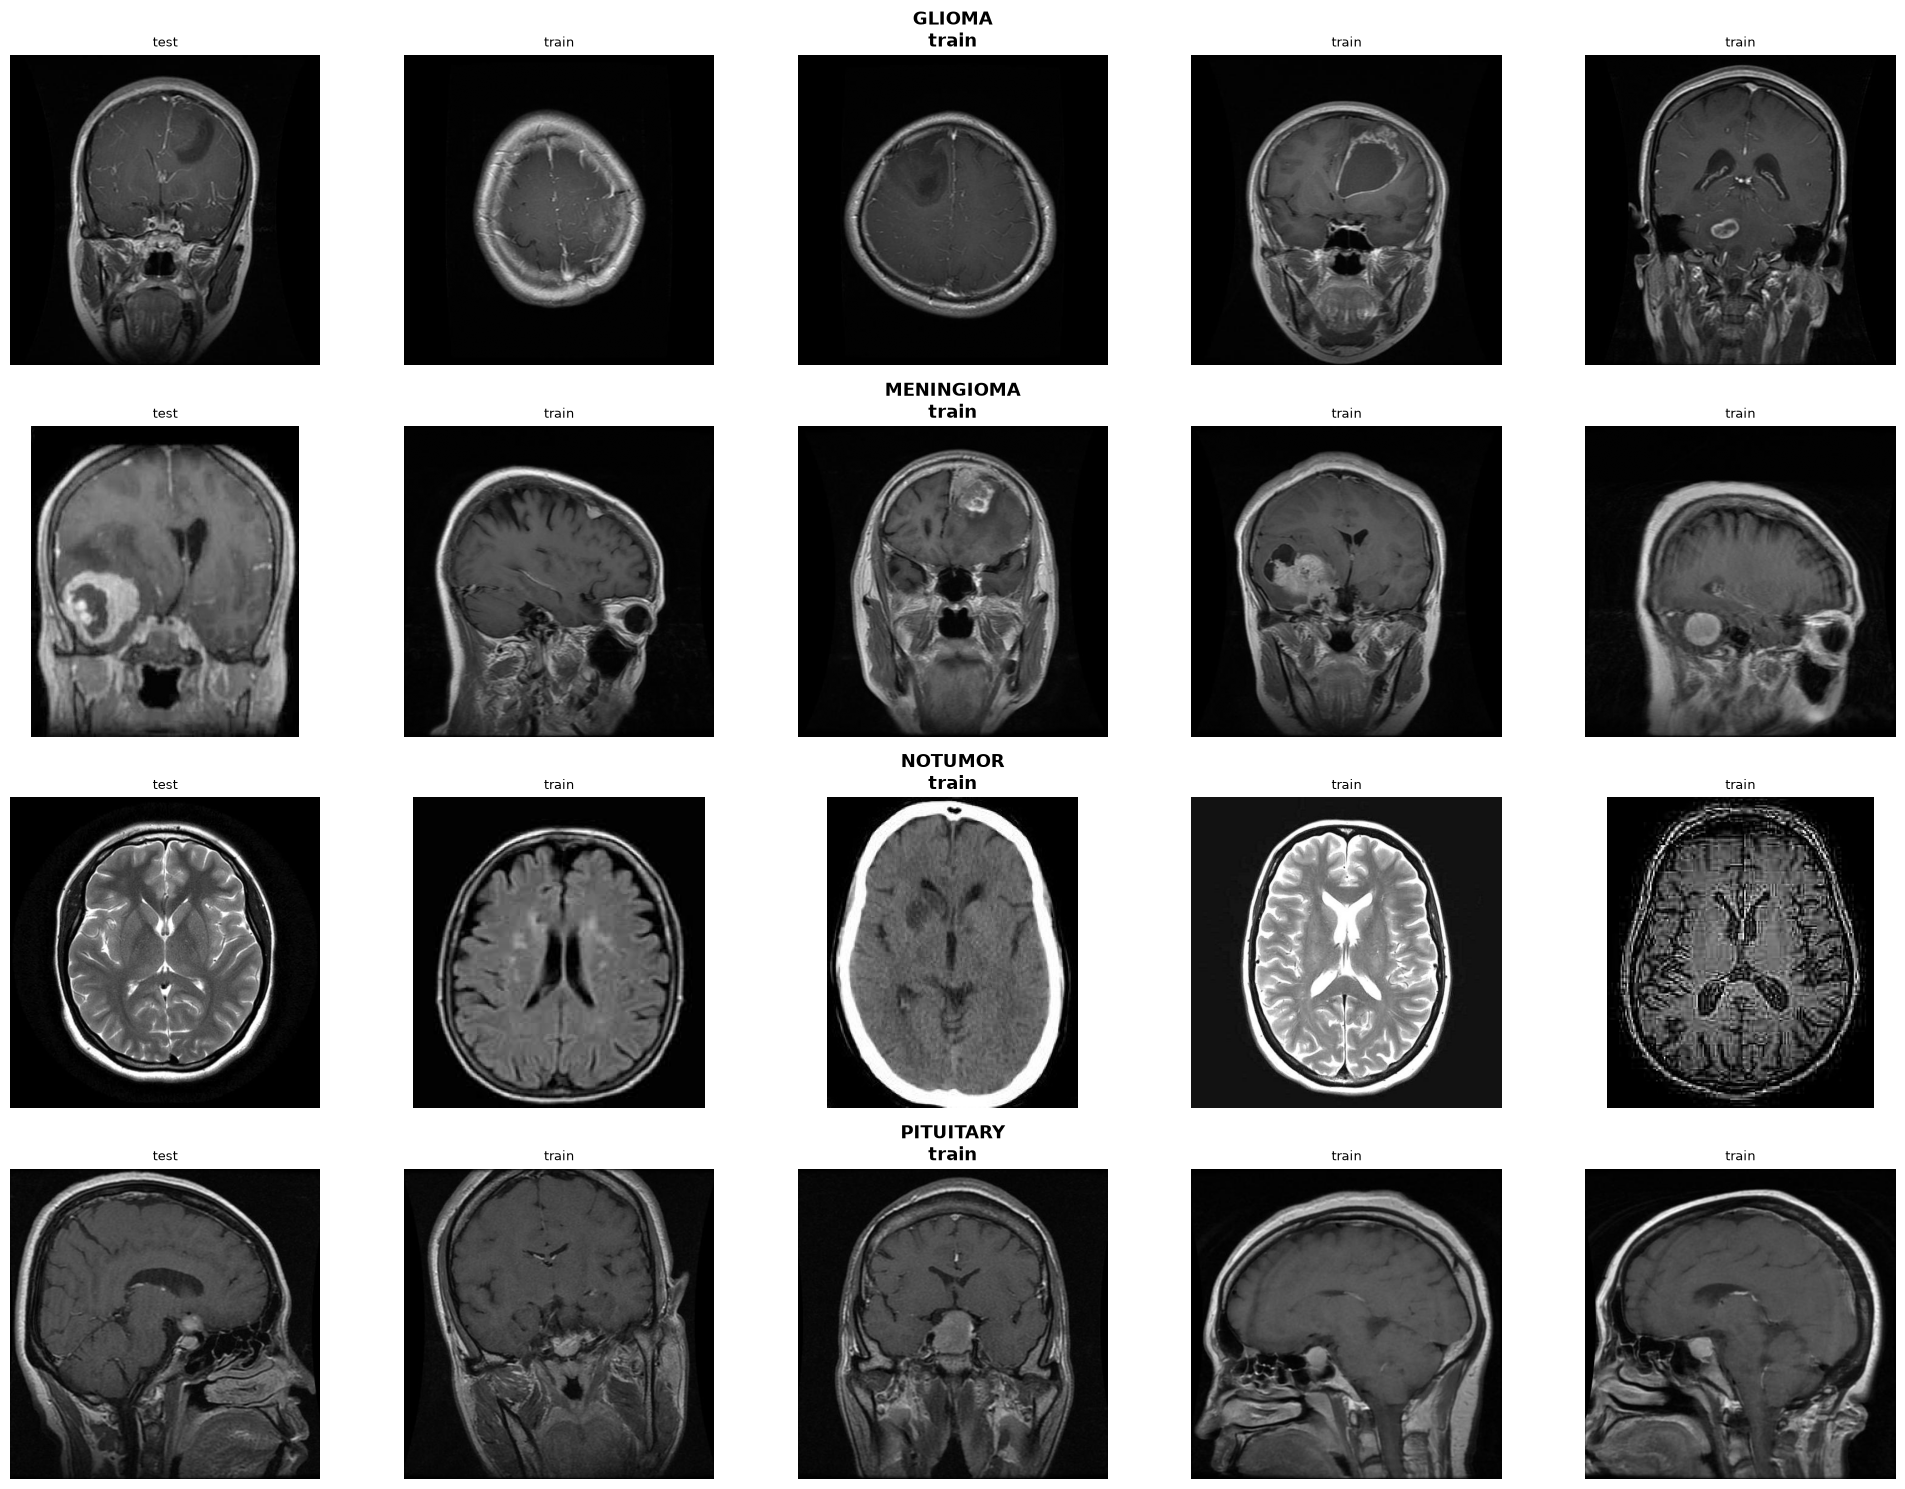

In [21]:
fig, axes = plt.subplots(4, 5, figsize=(20, 15))

for i, label in enumerate(classes):

    samples = df_images[
        df_images["label"] == label
    ].sample(5, random_state=42)

    for j, row in enumerate(samples.itertuples()):

        img = Image.open(row.path)

        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")

        axes[i, j].set_title(row.split, fontsize=9)

        if j == 2:
            axes[i, j].set_title(
                f"{label.upper()}\n{row.split}",
                fontsize=13,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

Conclusiones:

- A pesar de haber encontrado imágenes de RM de distintos cortes. Se decide no discriminar por cortes axiales, sagitales y coronales, ya que identificar el tumor es relativamente visible. La resonancia magnética sirve para diferenciar la materia gris, blanca y los tejidos tumorales. Además, tampoco es conveniente hacer esa discriminación inicial por que el dataset no es lo suficientemente grande para el aprendizaje.
- Por otro lado, se cree que la red neuronal es lo suficientemente inteligente para aprender a detectar las características de un tumor (texturas, bordes anómalos), independiente al tipo de corte, siempre y cuando las imágenes estén correctamente etiquetadas y en un mismo formato. 

- Asimismo, se observan diferencias en el contraste y la intensidad de las imágenes, probablemente asociadas a distintos protocolos de adquisición de resonancia magnética.

- Antes del entrenamiento será necesario unificar todas las imágenes a un mismo formato para garantizar la consistencia de entrada de la red neuronal.
- Antes edl entrenamiento se deberá considerar en que escala de colores estarán las imágenes.

### Preparación para CNN

Tras el EDA, se decide aplicar tres pasos de preprocesamiento: 
1. Redimensionamiento de todas las imágenes a 512 pixeles para unificar las dimensiones de entrada.
2. Conversión a escala de grises para homogeneizar los formatos de color y reducir la complejidad computacional.
3. Normalización de los valores de píxeles al rango [0,1] para facilitar el proceso de aprendizaje de la red neuronal.

Primero se hará un modelo de clasificador de imágenes binario:

tumor     = glioma + meningioma + pituitary
notumor   = notumor


Para train (Total 2800 imágenes):

notumor: 1400 originales.
tumor: Copiamos 1400 en total. Para que el modelo aprenda de todos los tipos por igual, extraeremos aleatoriamente unas 466 de glioma, 466 de meningioma y 468 de pituitary.

Para test (Total 800 imágenes):

notumor:400 originales.
tumor: Copiamos 400 en total (133 de glioma, 133 de meningioma, 134 de pituitary).


Pregunta que resuelve es: ¿Hay tumor o no hay tumor?
Dependiendo del accuracy y recall se valorará otro modelo para diferenciar el tipo de tumor

No obstante, como se dijo en el EDA, el dataset se encuentra desbalanceado para hacer un modelo binario. hay más proporción de imágenes tumor

PREPARACIÓN PARA MODELO BINARIO

1. Creación de dataset binario

In [51]:
random.seed(42)
#rutas oiginales
source_train = Path("../data/processed/train")
source_test = Path("../data/processed/test")

binary_train = Path("../data/processed/binary/train")
binary_test = Path("../data/processed/binary/test")

for folder in [
    binary_train / "tumor",
    binary_train / "notumor",
    binary_test / "tumor",
    binary_test / "notumor"
]:
    folder.mkdir(parents=True, exist_ok=True)

2. Balanceo del dataset binario

In [52]:
#función para copiar imágenes a la nueva ruta
def copy_images(image_paths, destination_folder):
    for img_path in image_paths:
        shutil.copy2(img_path, destination_folder / img_path.name)

In [53]:
# Copiar todas las imágenes notumor de train
notumor_train = list((source_train / "notumor").glob("*"))
copy_images(notumor_train, binary_train / "notumor")

# Seleccionar imágenes tumorales balanceadas desde las 3 clases
glioma_train = random.sample(list((source_train / "glioma").glob("*")), 466)
meningioma_train = random.sample(list((source_train / "meningioma").glob("*")), 466)
pituitary_train = random.sample(list((source_train / "pituitary").glob("*")), 468)

tumor_train = glioma_train + meningioma_train + pituitary_train
copy_images(tumor_train, binary_train / "tumor")

In [54]:
# Copiar todas las imágenes notumor de test
notumor_test = list((source_test / "notumor").glob("*"))
copy_images(notumor_test, binary_test / "notumor")

# Seleccionar imágenes tumorales balanceadas desde las 3 clases
glioma_test = random.sample(list((source_test / "glioma").glob("*")), 133)
meningioma_test = random.sample(list((source_test / "meningioma").glob("*")), 133)
pituitary_test = random.sample(list((source_test / "pituitary").glob("*")), 134)

tumor_test = glioma_test + meningioma_test + pituitary_test
copy_images(tumor_test, binary_test / "tumor")

In [56]:
#comprobar cantidad en cada carpeta
for split_path in [binary_train, binary_test]:
    print(split_path)
    for class_folder in split_path.iterdir():
        print(class_folder.name, len(list(class_folder.glob("*"))))

../data/processed/binary/train
notumor 1400
tumor 1400
../data/processed/binary/test
notumor 400
tumor 400


Normalización del dataset

In [37]:
IMG_SIZE = (512, 512) #redimensionamiento
BATCH_SIZE = 16    #grupos de 32
COLOR_MODE = "grayscale" #conersión a escala de grises

In [58]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/binary/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/binary/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    label_mode="binary",
    shuffle=False
)

Found 2800 files belonging to 2 classes.
Found 800 files belonging to 2 classes.


In [60]:
# Nombres de las clases detectadas automáticamente desde las carpetas
class_names = train_dataset.class_names

print("clases en train:",class_names)

clases en train: ['notumor', 'tumor']


In [63]:
#CHEQUEO DE la forma de un batch de imágenes y etiquetas
for images, labels in train_dataset.take(1):
    print("Forma de las imágenes:", images.shape)
    print("Forma de las etiquetas:", labels.shape)

Forma de las imágenes: (16, 512, 512, 1)
Forma de las etiquetas: (16, 1)


Conclusiones del preprocesamiento:

- Se realizará primero un modelo binario para clasificar tumor/notumor. Para esto se realizó un balanceo nuevo de imagenes considerando el split train 2800/ test 800.
- Tras el proceso de preparación de datos, todas las imágenes fueron redimensionadas a 512X512 píxeles y convertidas a escala de grises. 


### Modelo 1: CNN para Clasificación Binaria (Tumor vs. No Tumor)

In [77]:
# Definición de la CNN

model_1_binary = Sequential([
    
    # Normalización de píxeles dentro del modelo: [0,255] -> [0,1]
    Rescaling(1./255, input_shape=(512, 512, 1)),
    
    # Primer bloque convolucional
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Segundo bloque convolucional
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Tercer bloque convolucional
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Conversión de matriz a vector
    GlobalAveragePooling2D(),
    
    # Capa densa para aprender combinaciones de características
    Dense(128, activation="relu"),
    
    # Dropout para reducir overfitting
    Dropout(0.5),
    
    # # Capa final: clasificación binaria (tumor / no tumor)
    Dense(1, activation="sigmoid"),
])

/home/melissa/venvs/brain-tf-gpu/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [78]:
model_summary = model_1_binary.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# Compilación del modelo

model_1_binary.compile(
    optimizer=Adam(learning_rate=0.0001),#tamaño de pasos para que la red neuronal aprenda 
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Se utiliza el optimizador Adam por su buen rendimiento en problemas de visión por computador. 
La función de pérdida seleccionada es categorical_crossentropy, adecuada para problemas de clasificación multiclase.

In [81]:
#guardar automáticamente el mejor modelo

checkpoint = ModelCheckpoint(
    "../models/model_1_binary_tumor.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

#detener entrenamiento si deja de mejorar
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [83]:
history = model_1_binary.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20


I0000 00:00:1781983975.941634    4800 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_51623__.38


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4960 - loss: 0.6797
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../models/model_1_binary_tumor.keras

Epoch 1: finished saving model to ../models/model_1_binary_tumor.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.5000 - loss: 0.6688 - val_accuracy: 0.5000 - val_loss: 0.6689
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5313 - loss: 0.6191
Epoch 2: val_accuracy improved from 0.50000 to 0.71750, saving model to ../models/model_1_binary_tumor.keras

Epoch 2: finished saving model to ../models/model_1_binary_tumor.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5968 - loss: 0.5927 - val_accuracy: 0.7175 - val_loss: 0.5858
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8124 - loss: 0.4886
Epoch 3: val_accuracy improved from 0.71750 to 0.76125, saving model to ../models/model_1_binary_tumor.keras

Epoch 3: finished saving model to ../models

In [84]:
loss, accuracy = model_1_binary.evaluate(test_dataset)
print("Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7700 - loss: 0.5698
Accuracy: 0.7699999809265137


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


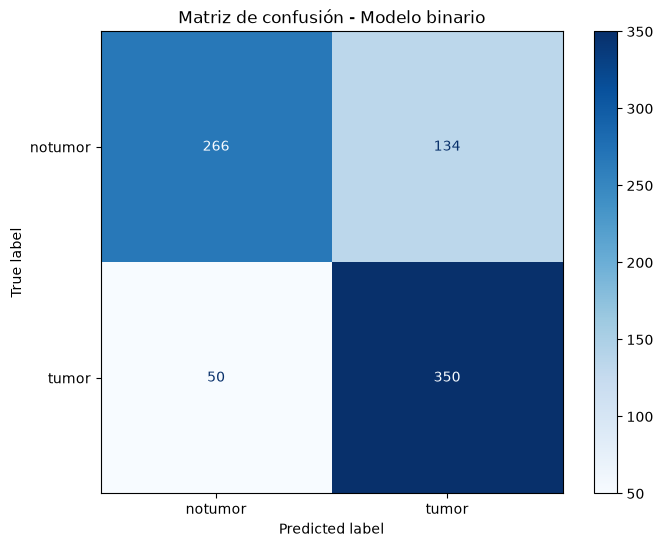

              precision    recall  f1-score   support

     notumor       0.84      0.67      0.74       400
       tumor       0.72      0.88      0.79       400

    accuracy                           0.77       800
   macro avg       0.78      0.77      0.77       800
weighted avg       0.78      0.77      0.77       800



In [87]:
# Probabilidades del modelo
y_pred_probs = model_1_binary.predict(test_dataset)

# Convertir probabilidades a clase: 0 o 1
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

# Etiquetas reales
y_true = np.concatenate([
    labels.numpy().astype("int32").flatten()
    for images, labels in test_dataset
])

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.class_names
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de confusión - Modelo binario")
plt.show()

# Reporte de métricas
print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_dataset.class_names
    )
)

Conclusión del modelo binario:
- El dataset inicial tiene 7200 y se tenían 4 clases (notumor, menningioma, glioma y pituitary). Sin embargo, se valoró la opción de hacer un modelo binario tumor/notumor.
- Para el modelo binario valorado, se identificó que se tiene data desbalanceada, ya que hay solo 1800 imágenes de no tumor y el resto de tumor son 5400 imágenes.
- Para el dataset del modelo binario, se escogen 3600 imágenes (2800 en train y 800 en test)



- El modelo binario dio un valor accuracy de 0.77 y un recall de 0.88 para tumor y 0.67 en no turmor. Esto quiere decir que el modelo identifica bien el 88% de casos donde los pacientes presentan tumores. Esto en medicina es muy importante. Se quiere siempre evitar que pacientes enfermos se clasifiquen como sanos.

- Por otro lado, el recall de la clase no tumor fue de 0.67, esto quiere decir que casos sanos son identificados como tumor. Si bien son casos de falsos positivos, resulta menos crítico desde una perspectiva médica comparado a no detectar un tumor existennte.

- A partir de este modelo se puede desarrollar una segunda capa con el objetivo de identificar el tipo de tumor únicamente para las identificadas como tumor.


- Una limitación del modelo es el tamaño del conjunto de datos, ya que se dispone de 7200 imágenes. A pesar de esto, la red neuronal pudo identificar correctamente la mayoría de los casos con tumor. Esto confirma que existen características visuales consistentes en las imágenes para que la CNN pueda aprenderlas y diferenciarlas.

### Modelo 2: CNN para Clasificación multiclase (glioma vs meningioma vs pituitary)

Como se sabe, el dataset inicial estaba bien balanceado por lo que aquí se usará las siguientes cantidades por split:

train: 4200 imágenes

test: 1200 imágenes

Solo se tomarán en cuenta los casos etiquetados como tumor.

Además se utilizarán las mismas características de prparación de datos antes del CNN (redimensionamientoen pixeles, normalizacion de gama de colores)

In [ ]:
#carga de data
train_dataset_type = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/tumor_type/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    label_mode="categorical"
)

test_dataset_type = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/tumor_type/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    label_mode="categorical",
    shuffle=False
)

Found 4200 files belonging to 3 classes.
Found 1200 files belonging to 3 classes.


In [109]:
# CHEQUEO Nombres de las clases detectadas automáticamente desde las carpetas
class_names_type = train_dataset_type.class_names

print("clases en train:",class_names_type)

clases en train: ['glioma', 'meningioma', 'pituitary']


In [110]:
#CHEQUEO DE la forma de un batch de imágenes y etiquetas
for images_, labels_ in train_dataset_type.take(1):
    print("Forma de las imágenes:", images_.shape)
    print("Forma de las etiquetas:", labels_.shape)

Forma de las imágenes: (16, 512, 512, 1)
Forma de las etiquetas: (16, 3)


In [142]:
# Definición de la CNN

model_2_type = Sequential([
    
    # Normalización de píxeles dentro del modelo: [0,255] -> [0,1]
    Rescaling(1./255, input_shape=(512, 512, 1)),
    
    # Primer bloque convolucional
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Segundo bloque convolucional
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Tercer bloque convolucional
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Conversión de matriz a vector
    GlobalAveragePooling2D(),
    
    # Capa densa para aprender combinaciones de características
    Dense(128, activation="relu"),
    
    # Dropout para reducir overfitting
    Dropout(0.5),
    
    # # Capa final: clasificación multiclase (3 tipos de tumor)
    Dense(3, activation="softmax")
])

/home/melissa/venvs/brain-tf-gpu/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [143]:
model_2_summary = model_2_type.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_12 (Rescaling)        │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,571 (428.01 KB)

 Trainable params: 109,571 (428.01 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
# Compilación del modelo

model_2_type.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",  #multiclase
    metrics=["accuracy"]
)

In [145]:
#guardar automáticamente el mejor modelo

checkpoint_2 = ModelCheckpoint(
    "../models/model_2_multiclass_tumor.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

#detener entrenamiento si deja de mejorar
early_stop_2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [146]:
history_2 = model_2_type.fit(
    train_dataset_type,
    validation_data=test_dataset_type,
    epochs=20,
    callbacks=[checkpoint_2, early_stop_2]
)

Epoch 1/20


I0000 00:00:1781998900.772396    4798 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137279__.46


262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3606 - loss: 1.0832

I0000 00:00:1781998916.560664    4797 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137279__.46


263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3609 - loss: 1.0831
Epoch 1: val_accuracy improved from None to 0.51250, saving model to ../models/model_2_multiclass_tumor.keras

Epoch 1: finished saving model to ../models/model_2_multiclass_tumor.keras
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.4336 - loss: 1.0483 - val_accuracy: 0.5125 - val_loss: 1.0297
Epoch 2/20
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5723 - loss: 0.8981
Epoch 2: val_accuracy improved from 0.51250 to 0.54667, saving model to ../models/model_2_multiclass_tumor.keras

Epoch 2: finished saving model to ../models/model_2_multiclass_tumor.keras
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.5826 - loss: 0.8869 - val_accuracy: 0.5467 - val_loss: 1.0400
Epoch 3/20
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5978 - loss: 0.8636
Epoch 3: val_accuracy improved from 0.54667 to 0.55417, saving model to ../models/model_2_multiclass_tumor.keras

Epoch 3: finished savin

In [147]:
loss_2, accuracy_2 = model_2_type.evaluate(test_dataset_type)
print("Accuracy:", accuracy_2)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6400 - loss: 0.9277
Accuracy: 0.6399999856948853


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


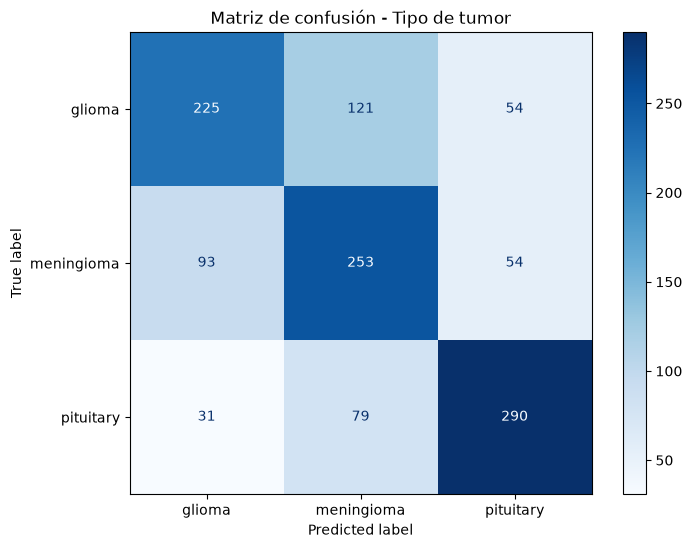

              precision    recall  f1-score   support

      glioma       0.64      0.56      0.60       400
  meningioma       0.56      0.63      0.59       400
   pituitary       0.73      0.72      0.73       400

    accuracy                           0.64      1200
   macro avg       0.64      0.64      0.64      1200
weighted avg       0.64      0.64      0.64      1200



In [148]:
y_pred_probs_2 = model_2_type.predict(test_dataset_type)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

y_true_2 = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_dataset_type
])

cm_2 = confusion_matrix(y_true_2, y_pred_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=test_dataset_type.class_names
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de confusión - Tipo de tumor")
plt.show()

print(
    classification_report(
        y_true_2,
        y_pred_2,
        target_names=test_dataset_type.class_names
    )
)

Notas:

Para el modelo 2 se usó la CNN con los mismos parámetros del modelo 1. Sin embargo, se obtuvo un accuracy de 0.63

Se realizará el siguiente ajustes con el objetivo de optimiar la red neuronal:


- Aumentar la profundidad del CNN, se añade un cuarto bloque convolucional, el objetivo es que aprenda patrones más complejos.

Conv2D(256, (3,3), activation="relu")
MaxPooling2D((2,2))

- Ajustes de dropout

Dropout(0.3)

Dado que el conjunto de datos no es extremadamente grande, un Dropout de 0.5 podía limitar excesivamente la capacidad de aprendizaje de la red.

- Se bajó el batch=8, antes se tenia batch=16
Esto fue necesario para evitar errores de memoria al entrenar conimágenes de 512.

Finalmente, con todos esos ajustes se espera aprovechar mejor el detalle de la imágenes médicas, reducir la confusión observada entre glioma y meningioma. Además, se desea mantener la estabilidad del entrenamiento utilizando la gpu actual.



#### OPTIMIZACIÓN DEL CNN DEL MODELO 2

In [149]:
train_dataset_type_v2 = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/tumor_type/train",
    image_size=IMG_SIZE,
    batch_size=8,
    color_mode=COLOR_MODE,
    label_mode="categorical"
)

test_dataset_type_v2 = tf.keras.utils.image_dataset_from_directory(
    "../data/processed/tumor_type/test",
    image_size=IMG_SIZE,
    batch_size=8,
    color_mode=COLOR_MODE,
    label_mode="categorical",
    shuffle=False
)

Found 4200 files belonging to 3 classes.
Found 1200 files belonging to 3 classes.


In [151]:
# Definición de la CNN

model_2_type_v2 = Sequential([
    
    # Normalización de píxeles dentro del modelo: [0,255] -> [0,1]
    Rescaling(1./255, input_shape=(512, 512, 1)),
    
    # Primer bloque convolucional
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Segundo bloque convolucional
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Tercer bloque convolucional
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    #cuarto bloque convolucional
    Conv2D(256, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    
    # Conversión de matriz a vector
    GlobalAveragePooling2D(),
    
    # Capa densa para aprender combinaciones de características
    Dense(128, activation="relu"),
    
    # Dropout para reducir overfitting
    Dropout(0.3),
    
    # # Capa final: clasificación multiclase (3 tipos de tumor)
    Dense(3, activation="softmax")
])

In [152]:
model_2_summary_v2 = model_2_type_v2.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 510, 510, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,123 (1.61 MB)

 Trainable params: 421,123 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [153]:
# Compilación del modelo

model_2_type_v2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",  #multiclase
    metrics=["accuracy"]
)

In [154]:
#guardar automáticamente el mejor modelo

checkpoint_2_v2 = ModelCheckpoint(
    "../models/model_2_multiclass_tumor_v2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

#detener entrenamiento si deja de mejorar
early_stop_2_v2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

In [155]:
history_2_v2 = model_2_type_v2.fit(
    train_dataset_type_v2,
    validation_data=test_dataset_type_v2,
    epochs=20,
    callbacks=[checkpoint_2_v2, early_stop_2_v2]
)

Epoch 1/20


I0000 00:00:1781999195.285233    4797 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_164573__.55


525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4546 - loss: 1.0187
Epoch 1: val_accuracy improved from None to 0.54583, saving model to ../models/model_2_multiclass_tumor_v2.keras

Epoch 1: finished saving model to ../models/model_2_multiclass_tumor_v2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.5386 - loss: 0.9342 - val_accuracy: 0.5458 - val_loss: 1.0176
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6121 - loss: 0.8473
Epoch 2: val_accuracy improved from 0.54583 to 0.55667, saving model to ../models/model_2_multiclass_tumor_v2.keras

Epoch 2: finished saving model to ../models/model_2_multiclass_tumor_v2.keras
525/525 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.6157 - loss: 0.8423 - val_accuracy: 0.5567 - val_loss: 0.9999
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6136 - loss: 0.8369
Epoch 3: val_accuracy improved from 0.55667 to 0.56250, saving model to ../models/model_2_multiclass_tumor_v2.keras

Epoch 3:

In [156]:
loss_2_v2, accuracy_2_v2 = model_2_type_v2.evaluate(test_dataset_type_v2)
print("Accuracy:", accuracy_2_v2)

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6875 - loss: 0.8122
Accuracy: 0.6875


150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


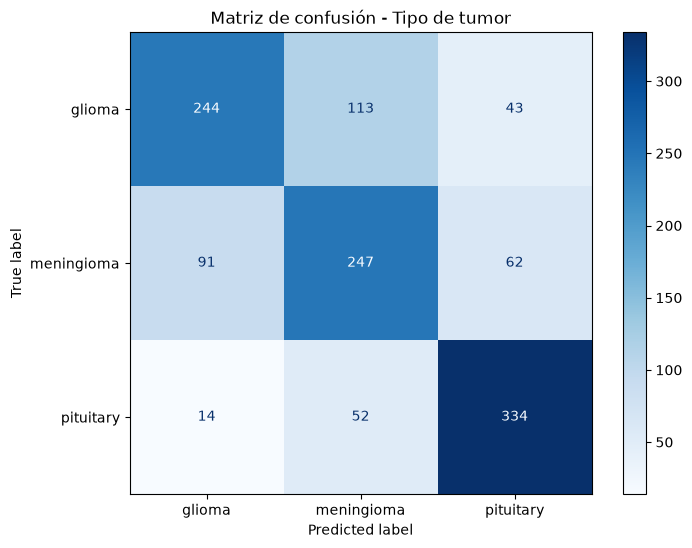

              precision    recall  f1-score   support

      glioma       0.70      0.61      0.65       400
  meningioma       0.60      0.62      0.61       400
   pituitary       0.76      0.83      0.80       400

    accuracy                           0.69      1200
   macro avg       0.69      0.69      0.69      1200
weighted avg       0.69      0.69      0.69      1200



In [157]:
y_pred_probs_2_v2 = model_2_type_v2.predict(test_dataset_type_v2)
y_pred_2_v2 = np.argmax(y_pred_probs_2_v2, axis=1)

y_true_2_v2 = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for images, labels in test_dataset_type_v2
])

cm_2_v2 = confusion_matrix(y_true_2_v2, y_pred_2_v2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2_v2,
    display_labels=test_dataset_type_v2.class_names
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", values_format="d", ax=ax)
plt.title("Matriz de confusión - Tipo de tumor")
plt.show()

print(
    classification_report(
        y_true_2_v2,
        y_pred_2_v2,
        target_names=test_dataset_type_v2.class_names
    )
)

Conclusiones:
- Se visualiza que el accuracy de la optimización aumentó, de 0.64 inicial ahora se tiene 0.69. 
Los resultados del modelo 2 inicial fueron los siguientes. Si embargo, se visualiza dificultad para diferenciar entre glioma y meningioma.

| Clase      | Precision | Recall | F1-score |
| ---------- | --------- | ------ | -------- |
| Glioma     | 0.64      | 0.56   | 0.60     |
| Meningioma | 0.56      | 0.63   | 0.59     |
| Pituitary  | 0.73      | 0.72   | 0.73     |


acurracy:0.64


- Para optimizar el modelo se consideró: añadir un cuarto bloque convolucionar (256 filtros), reducción del valor dropout de 0.5 a 0.3 y ajuste de bacth=8 para adaptarse al mayor consumo de memoria. 

| Clase      | Precision | Recall | F1-score |
| ---------- | --------- | ------ | -------- |
| Glioma     | 0.70      | 0.61   | 0.65     |
| Meningioma | 0.60      | 0.62   | 0.61     |
| Pituitary  | 0.76      | 0.83   | 0.80     |

accuracy:0.69

- Comparación del modelo 2 inicial y optimizado.


| Clase      | Recall inicial | Recall optimizado |
| ---------- | -------------- | ----------------- |
| Glioma     | 0.56           | 0.61              |
| Meningioma | 0.63           | 0.62              |
| Pituitary  | 0.72           | 0.83              |




La mejora fue especialmente notable en la detección de tumores Pituitary, cuyo recall pasó de 0.72 a 0.83. Sin embargo, el modelo continúa mostrando dificultades para diferenciar entre Glioma y Meningioma, ya que ambos tipos presentan características visuales similares en las imágenes de resonancia magnética.

✅ Modelo 1 (Tumor vs No Tumor): 0.77 accuracy y recall tumor 0.88

✅ Modelo 2 (Tipo de tumor): 0.69 accuracy.